Import delle librerie

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

AttributeError: partially initialized module 'pandas' has no attribute '_pandas_datetime_CAPI' (most likely due to a circular import)

In [ ]:
df = pd.read_csv("../data/raw/college_student_placement_dataset.csv")

print(f"Shape: {df.shape[0]:,} righe × {df.shape[1]} colonne\n")

print("Prime righe del dataset:")
print(df.head())

print("Descrizione categorie numeriche:")
display(df.describe())

print("Descrizione categorie numeriche:")
display(df.describe(include=['object', 'category']))

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_%': missing_pct.round(2)
}).sort_values('Missing_Count', ascending=False)
print(missing_df)
print(f"\n Valori mancanti: {missing.sum()} ({missing.sum()/len(df)*100:.2f}%)")

print("Distribuzione di placement:")
placement_dist = df['Placement'].value_counts()
placement_pct = df['Placement'].value_counts(normalize=True) * 100
print(pd.DataFrame({
    'Count': placement_dist,
    'Percentage': placement_pct.round(2)
}))
print(f"\n Dataset {'sbilanciato' if placement_pct.max() > 70 else 'bilanciato'}")




Shape: 10,000 righe × 10 colonne

Prime righe del dataset:
  College_ID   IQ  Prev_Sem_Result  CGPA  Academic_Performance  \
0    CLG0030  107             6.61  6.28                     8   
1    CLG0061   97             5.52  5.37                     8   
2    CLG0036  109             5.36  5.83                     9   
3    CLG0055  122             5.47  5.75                     6   
4    CLG0004   96             7.91  7.69                     7   

  Internship_Experience  Extra_Curricular_Score  Communication_Skills  \
0                    No                       8                     8   
1                    No                       7                     8   
2                    No                       3                     1   
3                   Yes                       1                     6   
4                    No                       8                    10   

   Projects_Completed Placement  
0                   4        No  
1                   0        No  
2  

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


Descrizione categorie numeriche:


,College_ID,Internship_Experience,Placement
count,10000,10000,10000
unique,100,2,2
top,CLG0062,No,No
freq,133,6036,8341


                        Missing_Count  Missing_%
College_ID                          0        0.0
IQ                                  0        0.0
Prev_Sem_Result                     0        0.0
CGPA                                0        0.0
Academic_Performance                0        0.0
Internship_Experience               0        0.0
Extra_Curricular_Score              0        0.0
Communication_Skills                0        0.0
Projects_Completed                  0        0.0
Placement                           0        0.0

 Valori mancanti: 0 (0.00%)
Distribuzione di placement:
           Count  Percentage
Placement                   
No          8341       83.41
Yes         1659       16.59

 Dataset sbilanciato


Sostituzione colonne Yes/No in numeriche

In [ ]:
df['Placement'] = df['Placement'].map({'No': 0, 'Yes': 1})
df['Internship_Experience'] = df['Internship_Experience'].map({'No': 0, 'Yes': 1})
df.head()
df.to_csv('../data/processed/college_student_placement_clean.csv', index=False)

Grafici EDA

C:\Users\matte\AppData\Local\Temp\ipykernel_14512\3916787932.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Placement', palette=['#e74c3c', '#27ae60'])


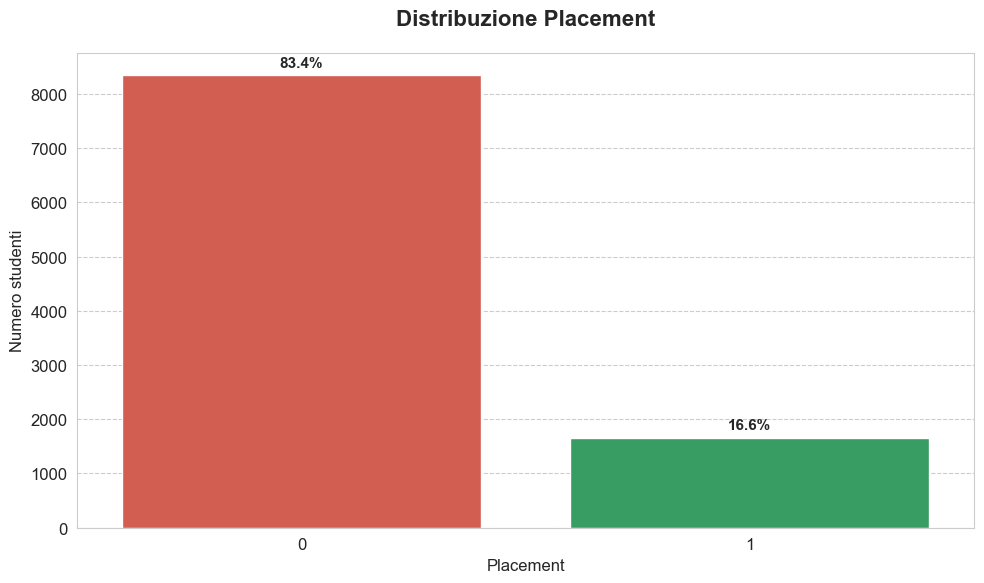

C:\Users\matte\AppData\Local\Temp\ipykernel_14512\3916787932.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Placement', y='CGPA', ax=axes[0], palette=['#e74c3c', '#27ae60'])
C:\Users\matte\AppData\Local\Temp\ipykernel_14512\3916787932.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Placement', y='CGPA', ax=axes[1], palette=['#e74c3c', '#27ae60'])


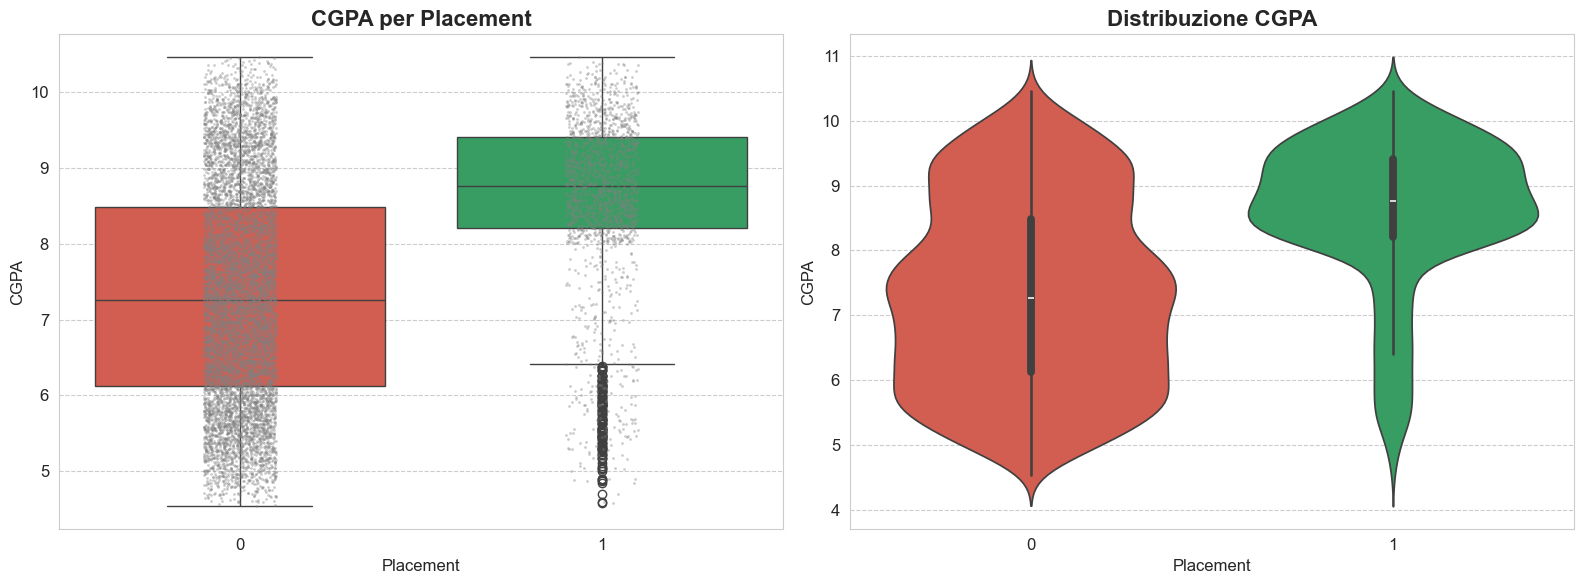

C:\Users\matte\AppData\Local\Temp\ipykernel_14512\3916787932.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Internship_Experience', palette=['#e74c3c', '#27ae60'])


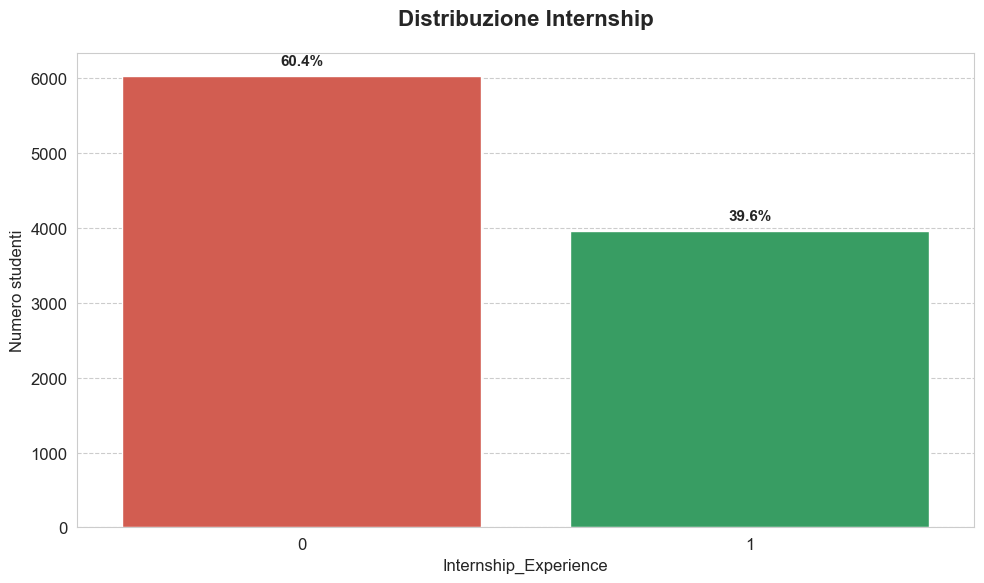

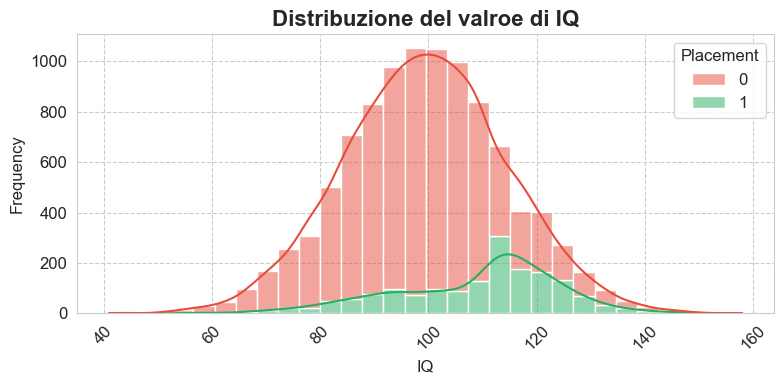

In [ ]:
#Setting dei parametri per i grafici
sns.set_style('whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_style("whitegrid", {'grid.linestyle': '--'})

#Grafico 1 - Distribuzione di Placement
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Placement', palette=['#e74c3c', '#27ae60'])
plt.title('Distribuzione Placement', fontweight='bold', pad=20)
plt.ylabel('Numero studenti')
counts = df['Placement'].value_counts()
for i, v in enumerate(counts):
    ax.text(i, v + 100, f'{v/len(df)*100:.1f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

#Grafico 2 - Per vedere relazione tra CGPA e Placement
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df, x='Placement', y='CGPA', ax=axes[0], palette=['#e74c3c', '#27ae60'])
sns.stripplot(data=df, x='Placement', y='CGPA', ax=axes[0], color='gray', alpha=0.4, size=2)
axes[0].set_title('CGPA per Placement')
sns.violinplot(data=df, x='Placement', y='CGPA', ax=axes[1], palette=['#e74c3c', '#27ae60'])
axes[1].set_title('Distribuzione CGPA')
plt.tight_layout()
plt.show()
#Si nota che un CGPA più alto fornisce più probabilità di Placement

#Grafico 3 - Distribuzione di internship
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Internship_Experience', palette=['#e74c3c', '#27ae60'])
plt.title('Distribuzione Internship', fontweight='bold', pad=20)
plt.ylabel('Numero studenti')
counts = df['Internship_Experience'].value_counts()
for i, v in enumerate(counts):
    ax.text(i, v + 100, f'{v/len(df)*100:.1f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

#Grafico 4 - Distribuzione del QI 
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df,
    x='IQ',
    kde=True,
    bins=30,
    hue='Placement',    
    multiple='stack',       
    palette=['#e74c3c', '#27ae60']
)
plt.title('Distribuzione del valroe di IQ')
plt.xlabel('IQ')
plt.ylabel('Frequenza')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#Si nota che mediamente chi ha un Placement ha QI più alto



Grafici di distribuzione delle variabili

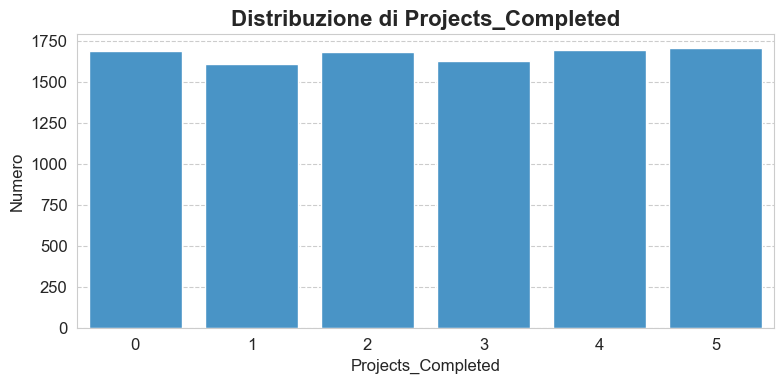

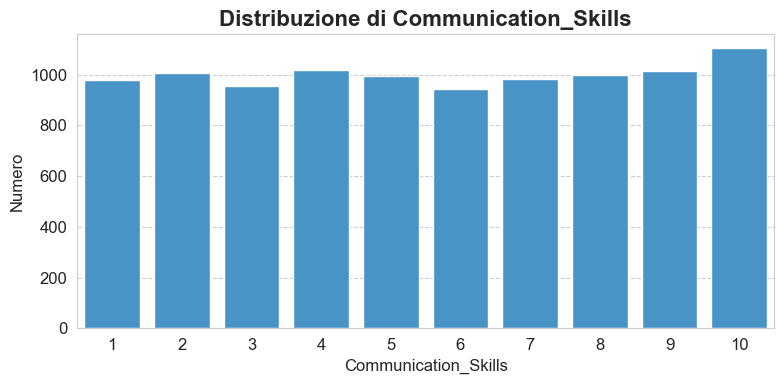

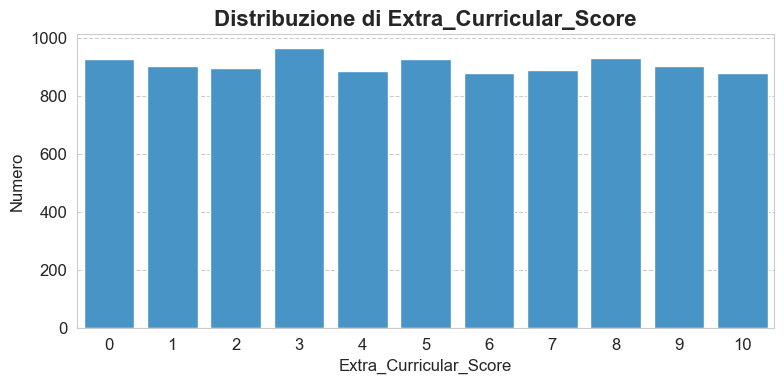

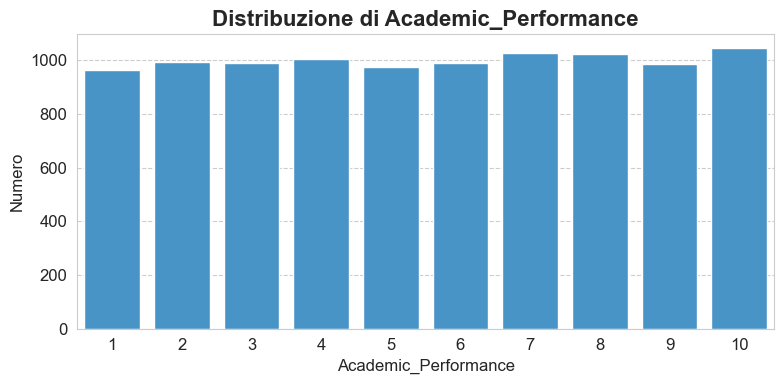

In [ ]:
#Setting dei parametri per i grafici
sns.set_style('whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_style("whitegrid", {'grid.linestyle': '--'})

cols = ['Projects_Completed', 'Communication_Skills',
        'Extra_Curricular_Score', 'Academic_Performance']

for col in cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, color='#3498db')
    plt.title(f'Distribuzione di {col}')
    plt.xlabel(col)
    plt.ylabel('Numero')
    plt.tight_layout()
    plt.show()


Statistiche sui college

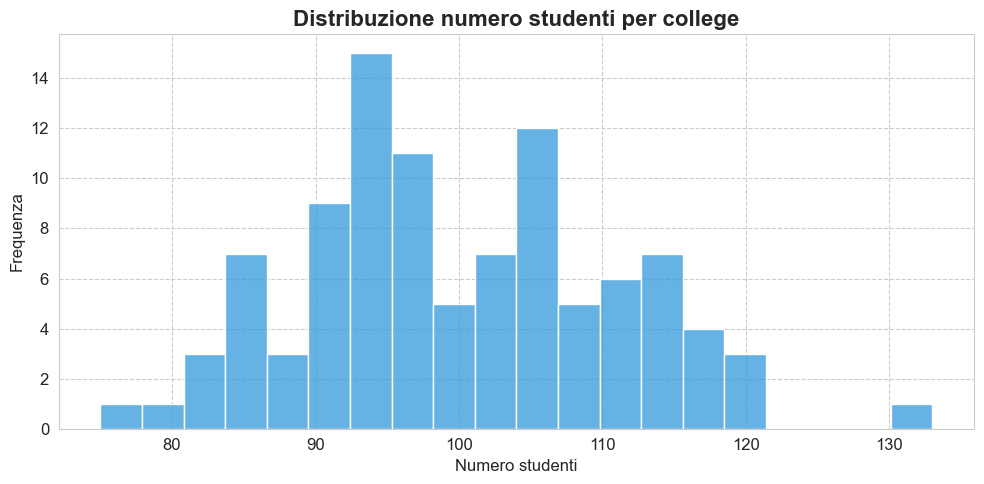

C:\Users\matte\AppData\Local\Temp\ipykernel_14512\237413392.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_colleges,


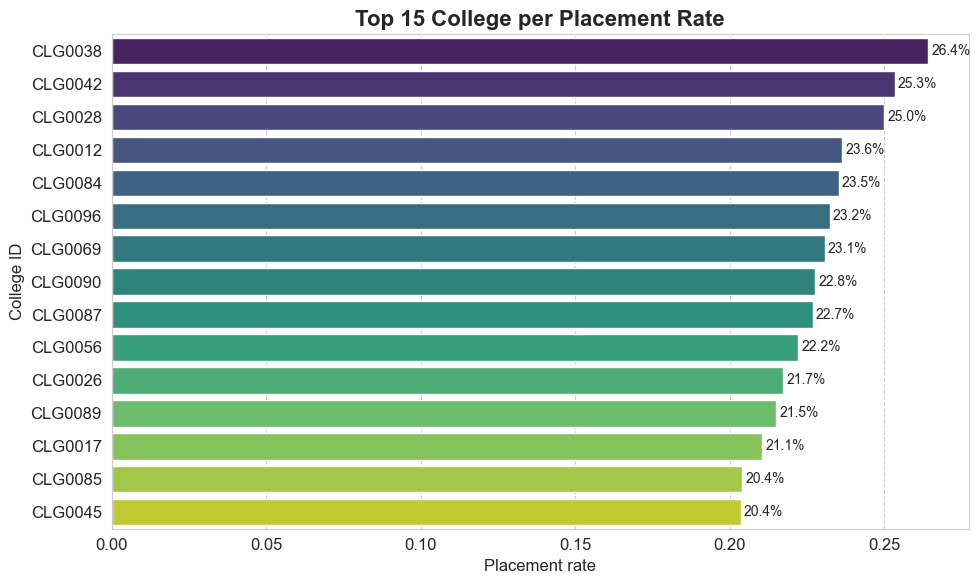

C:\Users\matte\AppData\Local\Temp\ipykernel_14512\237413392.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_colleges,


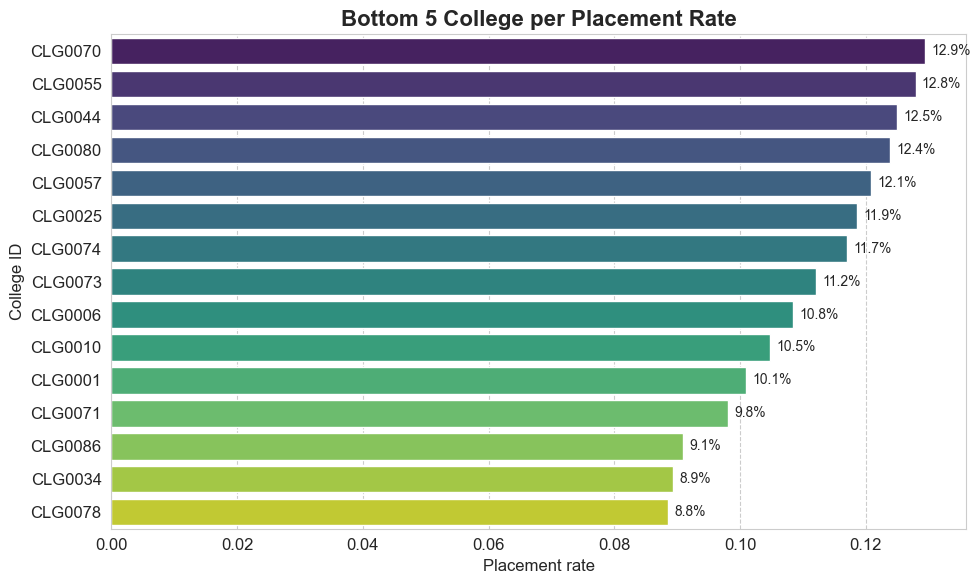

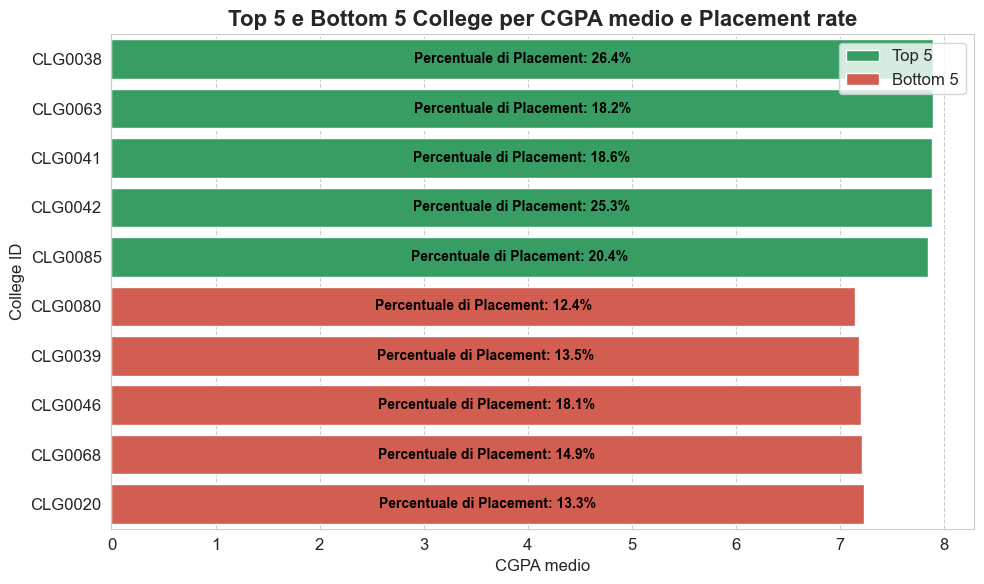

In [ ]:
#Setting dei parametri per i grafici
sns.set_style('whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_style("whitegrid", {'grid.linestyle': '--'})

college_stats = (
    df.groupby('College_ID')['Placement']
      .agg(['mean', 'count'])
      .reset_index()
)
college_stats.rename(columns={'mean': 'Placement_Rate',
                              'count': 'Num_Students'}, inplace=True)

#Grafico 1 - Distribuzione numero studenti per college
plt.figure(figsize=(10, 5))
sns.histplot(data=college_stats, x='Num_Students',color='#3498db', bins=20)
plt.title('Distribuzione numero studenti per college')
plt.xlabel('Numero studenti')
plt.ylabel('Frequenza')
plt.tight_layout()
plt.show()

#Grafico 2 - Top 15 per placement rate
top_colleges = college_stats.sort_values('Placement_Rate', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_colleges,
            x='Placement_Rate', y='College_ID',
            palette='viridis')
plt.title('Top 15 College per Placement Rate')
plt.xlabel('Placement rate')
plt.ylabel('College ID')
for i, row in top_colleges.iterrows():
    plt.text(row['Placement_Rate'] + 0.001,       
             (top_colleges.index == i).argmax(),
             f"{row['Placement_Rate']:.1%}",
             va='center', fontsize=10)
plt.tight_layout()
plt.show()

#Grafico 3 - Bottom 15 per placement rate
bottom_colleges = college_stats.sort_values('Placement_Rate', ascending=True).head(15).sort_values('Placement_Rate', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=bottom_colleges,
            x='Placement_Rate', y='College_ID',
            palette='viridis')
plt.title('Bottom 15 College per Placement Rate')
plt.xlabel('Placement rate')
plt.ylabel('College ID')

for i, row in bottom_colleges.iterrows():
    plt.text(row['Placement_Rate'] + 0.001,
             (bottom_colleges.index == i).argmax(),
             f"{row['Placement_Rate']:.1%}",
             va='center', fontsize=10)

plt.tight_layout()
plt.show()

#Grafico 4 - Top 5 e Bottom 5 college per CGPA
college_cgpa = (
    df.groupby('College_ID')['CGPA']
      .mean()
      .reset_index()
      .rename(columns={'CGPA': 'CGPA_Mean'})
)
placement_rate = (
    df.groupby('College_ID')['Placement']
      .mean()
      .reset_index()
      .rename(columns={'Placement': 'Placement_Rate'})
)
college_stats = college_cgpa.merge(placement_rate, on='College_ID')

top5 = college_stats.sort_values('CGPA_Mean', ascending=False).head(5)
bottom5 = college_stats.sort_values('CGPA_Mean', ascending=True).head(5)

top5['Group'] = 'Top 5'
bottom5['Group'] = 'Bottom 5'
tb = pd.concat([top5, bottom5], ignore_index=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=tb,
    x='CGPA_Mean',
    y='College_ID',
    hue='Group',
    palette=['#27ae60', '#e74c3c']
)
plt.title('Top 5 e Bottom 5 College per CGPA medio e Placement rate')
plt.xlabel('CGPA medio')
plt.ylabel('College ID')
plt.legend()

for patch, (_, row) in zip(ax.patches, tb.iterrows()):
    x = patch.get_width() / 2          
    y = patch.get_y() + patch.get_height() / 2 
    ax.text(
        x,
        y,
        f"Percentuale di Placement: {row['Placement_Rate']*100:.1f}%",
        ha='center',
        va='center',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()



Grafici distribuzioni